# Radial wavefunctions of mixed Yb171 S-states in the FJ and LS coupling scheme

In the notebook `mqdt_exp_qn.ipynb` we looked at the expectation values of $J_{\mathrm{tot}}$ and $F_c$
for the Yb171 $S_{1/2}$ ($F_{\mathrm{tot}}=1/2$) Rydberg series.
For low $\nu$ the states have a well defined $J_{\mathrm{tot}}$ (LS coupling),
for high $\nu$ they have a well defined $F_c$ (FJ coupling).

In between there are states, where both $\langle J_{\mathrm{tot}} \rangle \approx 0.5$ and $\langle F_c \rangle \approx 0.5$
with a large standard deviation, i.e. they are described well by neither coupling scheme.
Here we pick some of these states and look at the radial wavefunctions of their channels,
once in the FJ and once in the LS coupling scheme.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks

import rydstate
from rydstate.angular.utils import get_spectroscopic_letter
from rydstate.rydberg_state import RydbergKet  # noqa: TC001

logging.getLogger("rydstate").setLevel(logging.ERROR)

## Basis

We use the same basis as in `mqdt_exp_qn.ipynb`.

In [2]:
nu = 0, 130
l_r = 0
f_tot = 1 / 2

basis = rydstate.BasisMQDT("Yb171", nu, l_r=(0, 1), f_tot=(f_tot, f_tot))

basis.filter_states("j_tot", (0, float("inf")))
basis.filter_states("f_c", (0, float("inf")))
basis.filter_states("f_tot", f_tot)
basis.filter_states("l_r", l_r, delta=0.5)
basis.filter_states("l_c", 0, delta=0.3)

basis.sort_states("nu")

print(f"{basis.species} basis states: {len(basis)}")
print(f"  nu_min = {basis.states[0].nu:.2f}, nu_max = {basis.states[-1].nu:.2f}")

Yb171 basis states: 262
  nu_min = 2.50, nu_max = 129.68


## Selecting the mixed states

We call a state *mixed*, if both $\langle J_{\mathrm{tot}} \rangle$ and $\langle F_c \rangle$ are close to $0.5$.
Since both quantum numbers can only take the values $0$ and $1$ here, this automatically implies a large standard deviation
($\sigma \approx 0.5$).

In [3]:
nu = basis.calc_exp_qn("nu")
exp_j = basis.calc_exp_qn("j_tot")
std_j = basis.calc_std_qn("j_tot")
exp_fc = basis.calc_exp_qn("f_c")
std_fc = basis.calc_std_qn("f_c")

# how far away from 0.5 both expectation values are
mixing_distance = np.abs(exp_j - 0.5) + np.abs(exp_fc - 0.5)
mixed_indices = np.argwhere(mixing_distance < 0.15).flatten()

print(f"{len(mixed_indices)} mixed states found:")
print(f"{'idx':>4} {'nu':>8} {'<J_tot>':>8} {'std':>6} {'<F_c>':>8} {'std':>6}")
for i in mixed_indices:
    print(f"{i:4d} {nu[i]:8.3f} {exp_j[i]:8.3f} {std_j[i]:6.3f} {exp_fc[i]:8.3f} {std_fc[i]:6.3f}")

8 mixed states found:
 idx       nu  <J_tot>    std    <F_c>    std
 153   77.616    0.465  0.499    0.489  0.500
 154   77.751    0.533  0.499    0.510  0.500
 196   98.624    0.455  0.498    0.544  0.498
 197   98.759    0.544  0.498    0.454  0.498
 227  113.609    0.521  0.500    0.438  0.496
 228  113.743    0.479  0.500    0.560  0.496
 250  124.625    0.467  0.499    0.544  0.498
 251  124.757    0.533  0.499    0.454  0.498


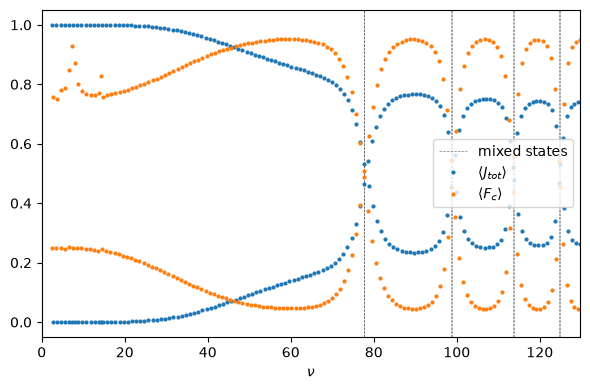

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))

for nu_mixed in nu[mixed_indices]:
    ax.axvline(nu_mixed, color="k", lw=0.5, ls="--", alpha=0.5)
ax.plot([], [], "k--", lw=0.5, alpha=0.5, label="mixed states")

ax.plot(nu, exp_j, "C0o", ms=2, label=r"$\langle J_{tot} \rangle$")
ax.plot(nu, exp_fc, "C1o", ms=2, label=r"$\langle F_c \rangle$")

ax.set_xlabel(r"$\nu$")
ax.set_xlim(0, nu[-1])
ax.set_ylim(-0.05, 1.05)
ax.legend(loc="center right")
fig.tight_layout()
plt.show()

## Channel wavefunctions in a given coupling scheme

An MQDT state is a superposition of channels $|\Psi\rangle = \sum_i c_i \, |\phi_i\rangle \, u_i(r)$,
where $|\phi_i\rangle$ is the angular (and core) part and $u_i(r)$ the radial wavefunction of channel $i$.
The state is originally given in the FJ coupling scheme, where each channel has a well defined
effective principal quantum number $\nu_i$ and thus a "clean" Coulomb radial wavefunction.

With `RydbergState.to_coupling_scheme` we can rewrite the state in the LS coupling scheme.
The new radial wavefunctions are linear combinations of the FJ channel wavefunctions
and are normalized again, so that the weight $|c_i|^2$ of each channel can be read off from the coefficient.

Below we plot $c_i \, w_i(z)$ with $z = \sqrt{r / a_0}$, so that the different channels are directly comparable in size.

In [5]:
def get_channels(
    state: rydstate.RydbergStateMQDT, coupling_scheme: str, min_weight: float = 1e-3
) -> list[tuple[float, RydbergKet]]:
    """Return the (coefficient, RydbergKet) of the relevant channels of the state in the given coupling scheme."""
    state_cs = state.to_coupling_scheme(coupling_scheme)
    channels = []
    for coeff, ket in state_cs:
        if ket.radial._is_dummy or coeff**2 < min_weight:  # noqa: SLF001
            continue
        channels.append((coeff, ket))
    return channels


def get_channel_label(coeff: float, ket: RydbergKet) -> str:
    """Return a short label for a channel."""
    angular = ket.angular
    if angular.coupling_scheme == "FJ":
        label = rf"$f_c = {angular.f_c:g}$, $\nu_i = {ket.radial.nu:.2f}$"
    elif angular.coupling_scheme == "LS":
        l_str = get_spectroscopic_letter(angular.l_tot).upper()
        label = rf"$^{{{2 * angular.s_tot + 1:g}}}{l_str}_{{{angular.j_tot:g}}}$"
    else:
        label = ket.get_label()
    return rf"{label}: $c_i = {coeff:+.2f}$, $|c_i|^2 = {coeff**2:.2f}$"


def plot_radial_channels(ax: plt.Axes, state: rydstate.RydbergStateMQDT, coupling_scheme: str, lw: float = 0.7) -> None:
    """Plot c_i * w_i(z) for all relevant channels of the state in the given coupling scheme."""
    for coeff, ket in get_channels(state, coupling_scheme):
        ax.plot(ket.radial.z_list, coeff * ket.radial.w_list, label=get_channel_label(coeff, ket), lw=lw)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel(r"$z = \sqrt{r / a_0}$")
    ax.set_ylabel(r"$c_i \, w_i(z)$")
    # make room for the legend above the wavefunctions
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + 0.6 * (y_max - y_min))
    ax.legend(loc="upper left", fontsize=8)

## Mixed states

We take the four most strongly mixed states (smallest distance of both expectation values to $0.5$).

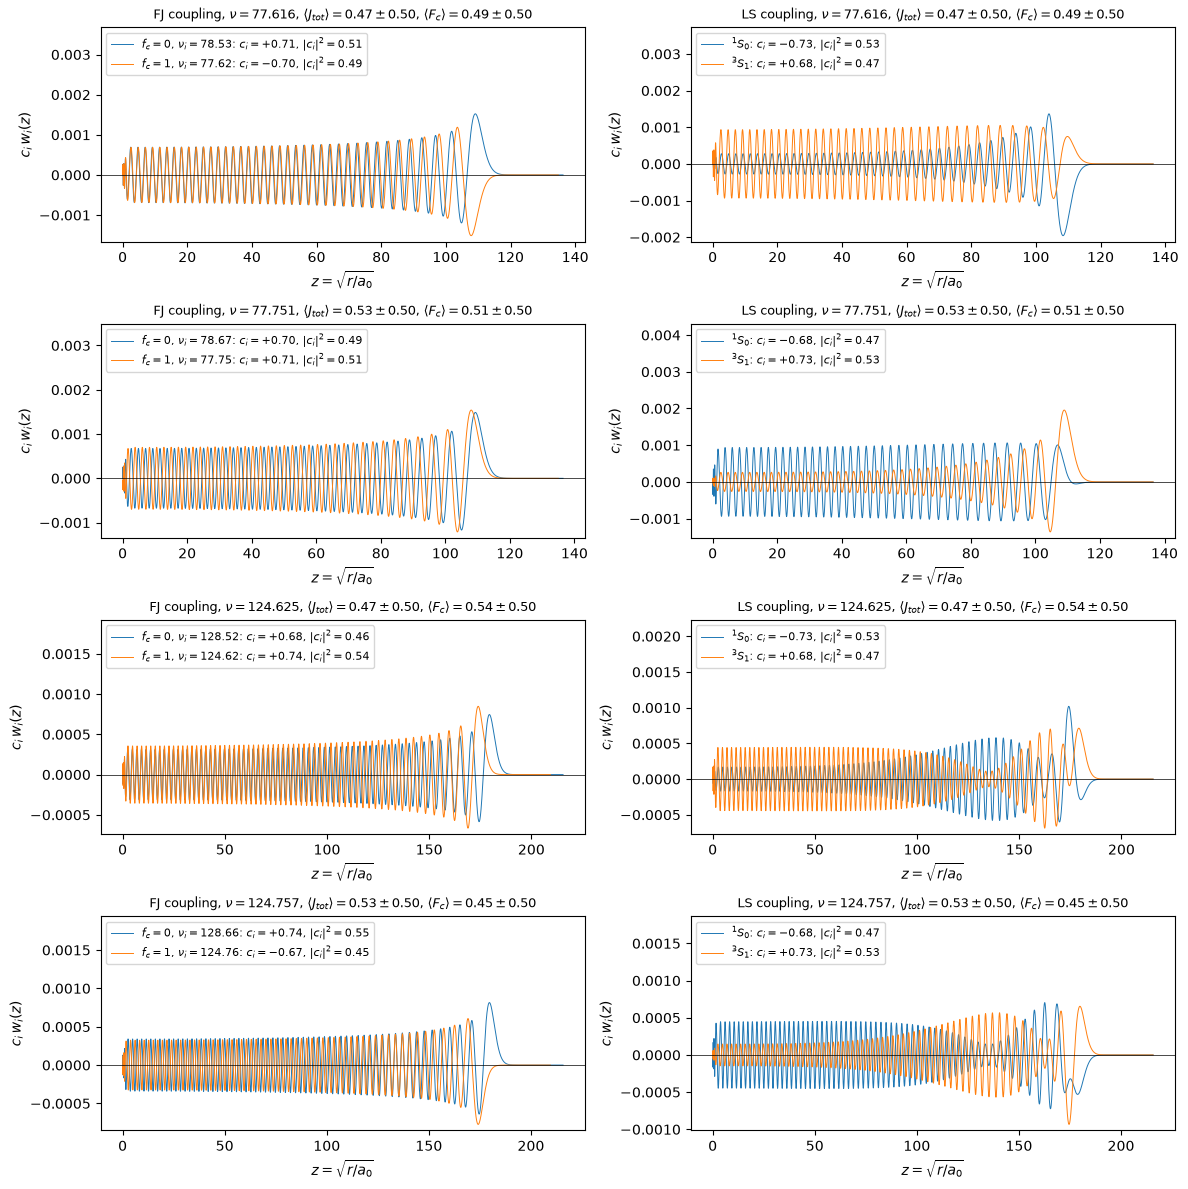

In [6]:
n_plot = 4
plot_indices = sorted(mixed_indices[np.argsort(mixing_distance[mixed_indices])[:n_plot]])

fig, axs = plt.subplots(n_plot, 2, figsize=(12, 3 * n_plot), sharex="row")
for row, i in enumerate(plot_indices):
    state = basis.states[i]
    for col, coupling_scheme in enumerate(["FJ", "LS"]):
        ax = axs[row, col]
        plot_radial_channels(ax, state, coupling_scheme)
        ax.set_title(
            rf"{coupling_scheme} coupling, $\nu = {nu[i]:.3f}$, "
            rf"$\langle J_{{tot}} \rangle = {exp_j[i]:.2f} \pm {std_j[i]:.2f}$, "
            rf"$\langle F_c \rangle = {exp_fc[i]:.2f} \pm {std_fc[i]:.2f}$",
            fontsize=9,
        )

fig.tight_layout()
plt.show()

**FJ coupling (left):**
Both channels ($f_c = 0$ and $f_c = 1$) have a clean single-$\nu_i$ Coulomb wavefunction.
The two channels are attached to the two hyperfine thresholds of the ion core, so their $\nu_i$ differ.
The difference $\Delta \nu_i \approx \nu^3 \, \Delta E_{\mathrm{hfs}} / (2 \, \mathrm{Ry})$ grows with $\nu$:
it is about $1$ for $\nu \approx 78$ and about $4$ for $\nu \approx 125$,
i.e. the two wavefunctions have a different number of nodes.
The weights are close to $50/50$, so $F_c$ is not a good quantum number, although each radial wavefunction on its own is simple.

**LS coupling (right):**
The $^1S_0$ ($J_{\mathrm{tot}} = 0$) and $^3S_1$ ($J_{\mathrm{tot}} = 1$) radial wavefunctions are (up to Clebsch-Gordan coefficients)
the sum and the difference of the two FJ channel wavefunctions.
Since the FJ wavefunctions are nearly in phase at short distances and drift out of phase towards the outer turning point,
the LS wavefunctions get a beating envelope (with more beats the larger $\Delta \nu_i$ is):
where one of them is large the other one is small and vice versa.
They do not have a well defined $\nu_i$ (note the `nu=None` of the radial wavefunction) and the weights are again close to $50/50$.

So for these states there is no coupling scheme, in which the state is dominated by a single channel with a simple radial wavefunction.

## Comparison to states, which are well described by one coupling scheme

For comparison we show a low-$\nu$ state with well defined $J_{\mathrm{tot}}$ (LS coupling)
and a high-$\nu$ state with well defined $F_c$ (FJ coupling).

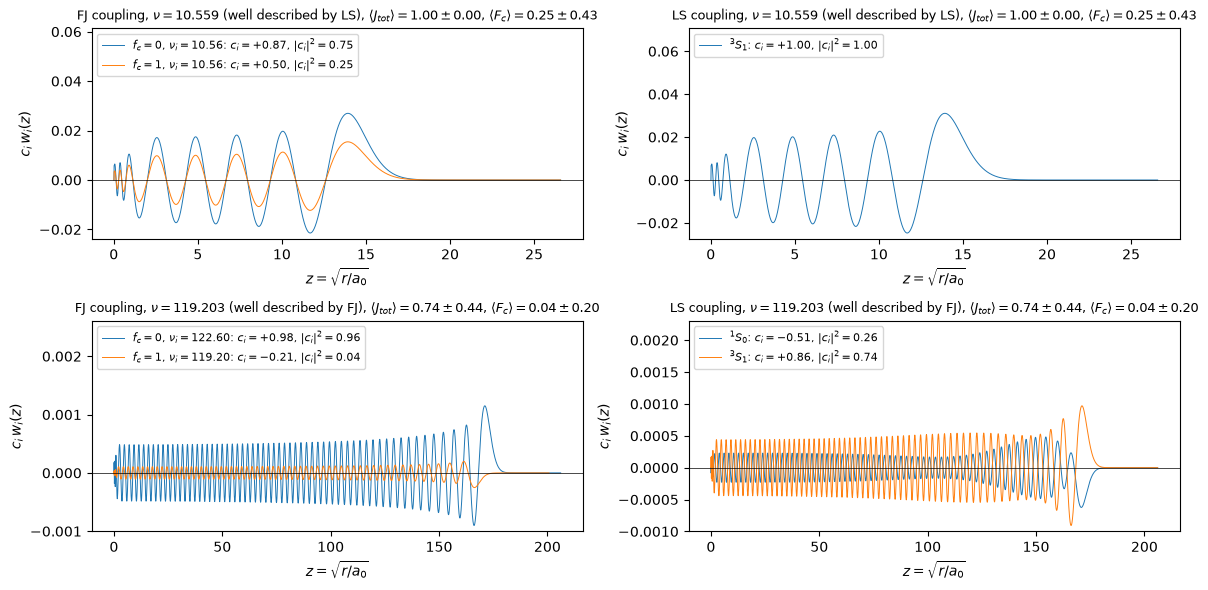

In [7]:
mask = nu > 10  # skip low lying states with strong perturber admixture
i_ls = np.argwhere(mask).flatten()[np.argmin(std_j[mask])]
i_fj = np.argwhere(mask).flatten()[np.argmin(std_fc[mask])]

fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex="row")
for row, (i, description) in enumerate([(i_ls, "well described by LS"), (i_fj, "well described by FJ")]):
    state = basis.states[i]
    for col, coupling_scheme in enumerate(["FJ", "LS"]):
        ax = axs[row, col]
        plot_radial_channels(ax, state, coupling_scheme)
        ax.set_title(
            rf"{coupling_scheme} coupling, $\nu = {nu[i]:.3f}$ ({description}), "
            rf"$\langle J_{{tot}} \rangle = {exp_j[i]:.2f} \pm {std_j[i]:.2f}$, "
            rf"$\langle F_c \rangle = {exp_fc[i]:.2f} \pm {std_fc[i]:.2f}$",
            fontsize=9,
        )

fig.tight_layout()
plt.show()

For the low-$\nu$ state the two FJ channels have almost the same $\nu_i$ (the hyperfine splitting of the core is small
compared to the level spacing), so their radial wavefunctions are nearly identical.
Their difference vanishes and the state is a pure $^3S_1$ state in LS coupling.

For the high-$\nu$ state the level spacing is smaller than the hyperfine splitting of the core,
the two FJ channel wavefunctions are very different and the state is dominated by a single FJ channel.
In LS coupling both channels carry a large weight and their radial wavefunctions show a strong beating.

## Channel resolved probability density

The amplitude plots show the phase relation between the channels, but the beating of the LS channels is easier to see
in the probability density.
In the coordinate $z = \sqrt{r / a_0}$ the radial probability density of channel $i$ is

$$\rho_i(z) = |c_i|^2 \, |u_i(r)|^2 \, \frac{\mathrm{d}r}{\mathrm{d}z} = 2 z^2 \, |c_i \, w_i(z)|^2 ,$$

so that the area under each curve is the weight $|c_i|^2$ of the channel.
The thin lines show $\rho_i(z)$, the thick lines its envelope (the local maxima of $\rho_i$ connected by straight lines).

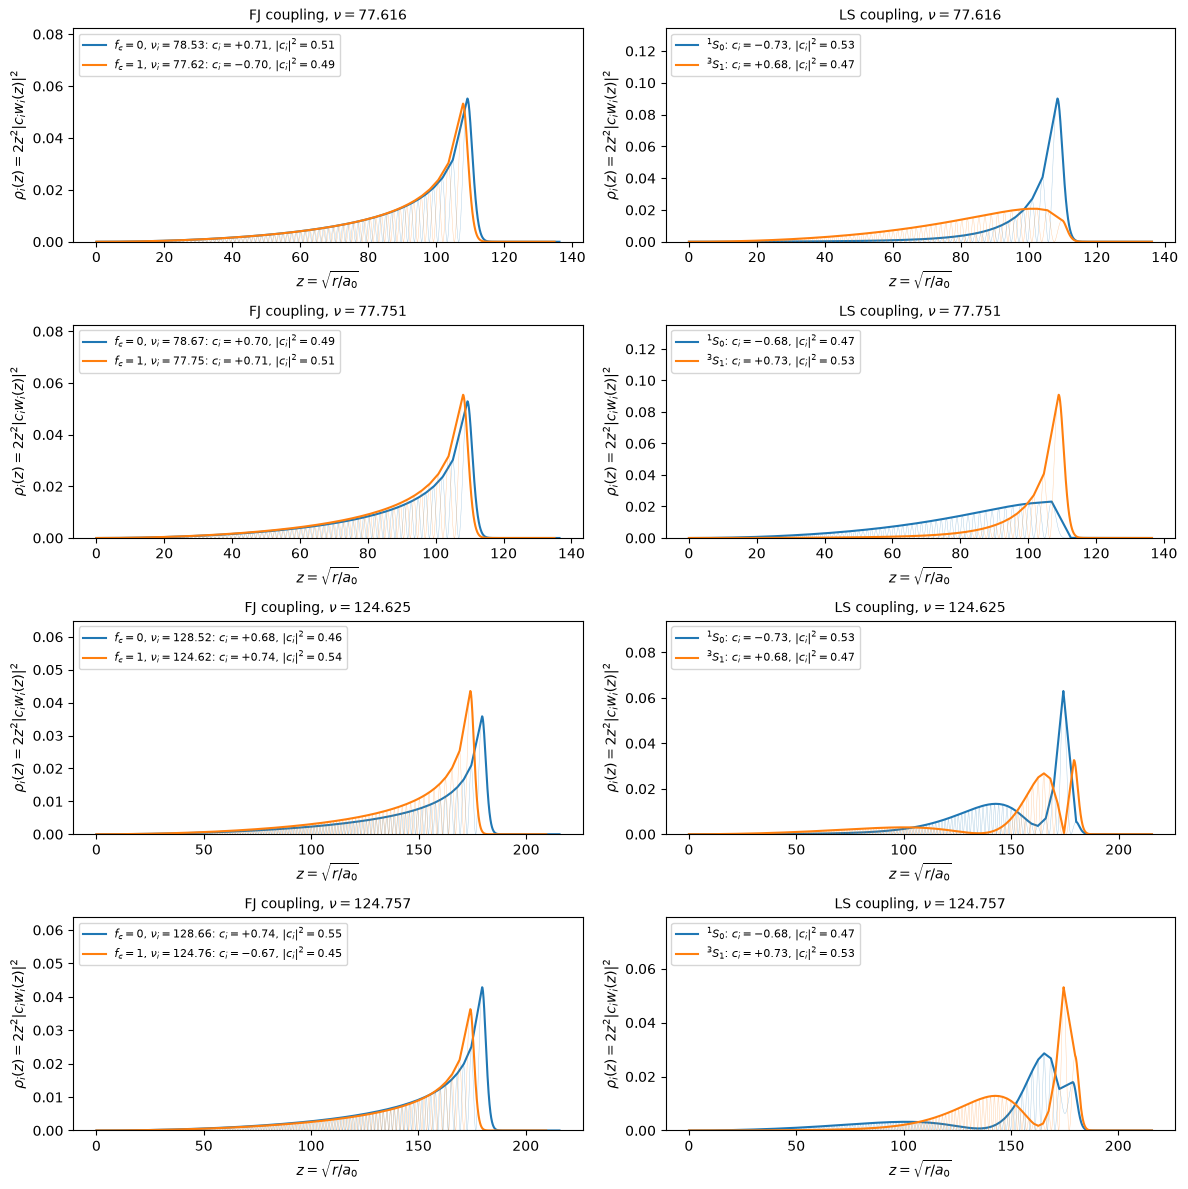

In [8]:
def calc_density(coeff: float, ket: RydbergKet) -> np.ndarray:
    """Return the radial probability density 2 z^2 |c_i w_i(z)|^2 of a channel on its z grid."""
    radial = ket.radial
    return 2 * radial.z_list**2 * (coeff * radial.w_list) ** 2


def calc_envelope(z_list: np.ndarray, density: np.ndarray) -> np.ndarray:
    """Return the envelope of an oscillating density by linear interpolation between its local maxima."""
    peaks, _ = find_peaks(density)
    envelope = np.interp(z_list, z_list[peaks], density[peaks])
    # before the first and after the last maximum the density itself is monotonic, so use it directly
    outside = (z_list < z_list[peaks[0]]) | (z_list > z_list[peaks[-1]])
    envelope[outside] = density[outside]
    return envelope


def plot_density_channels(ax: plt.Axes, state: rydstate.RydbergStateMQDT, coupling_scheme: str) -> None:
    """Plot the channel resolved probability density and its envelope in the given coupling scheme."""
    for j, (coeff, ket) in enumerate(get_channels(state, coupling_scheme)):
        z_list = ket.radial.z_list
        density = calc_density(coeff, ket)
        ax.plot(z_list, density, f"C{j}", lw=0.3, alpha=0.4)
        ax.plot(z_list, calc_envelope(z_list, density), f"C{j}", lw=1.5, label=get_channel_label(coeff, ket))
    ax.set_xlabel(r"$z = \sqrt{r / a_0}$")
    ax.set_ylabel(r"$\rho_i(z) = 2 z^2 |c_i w_i(z)|^2$")
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(0, y_max + 0.4 * (y_max - y_min))
    ax.legend(loc="upper left", fontsize=8)


fig, axs = plt.subplots(n_plot, 2, figsize=(12, 3 * n_plot), sharex="row")
for row, i in enumerate(plot_indices):
    state = basis.states[i]
    for col, coupling_scheme in enumerate(["FJ", "LS"]):
        ax = axs[row, col]
        plot_density_channels(ax, state, coupling_scheme)
        ax.set_title(rf"{coupling_scheme} coupling, $\nu = {nu[i]:.3f}$", fontsize=10)

fig.tight_layout()
plt.show()

In FJ coupling the envelopes are the smooth densities of two single-channel Coulomb wavefunctions, which differ only in their
extent (the channel with the larger $\nu_i$ reaches further out).
In LS coupling the envelopes beat: where the $^3S_1$ density is large the $^1S_0$ density is small and vice versa.
The FJ channels on the other hand carry comparable density everywhere.
On this linear scale the inner region is hardly visible, since most of the density sits close to the outer turning point.
The next section therefore integrates these densities up to a cut radius and evaluates the channel weights region by region.

For comparison, the same densities for the two states from above, which are well described by one coupling scheme.

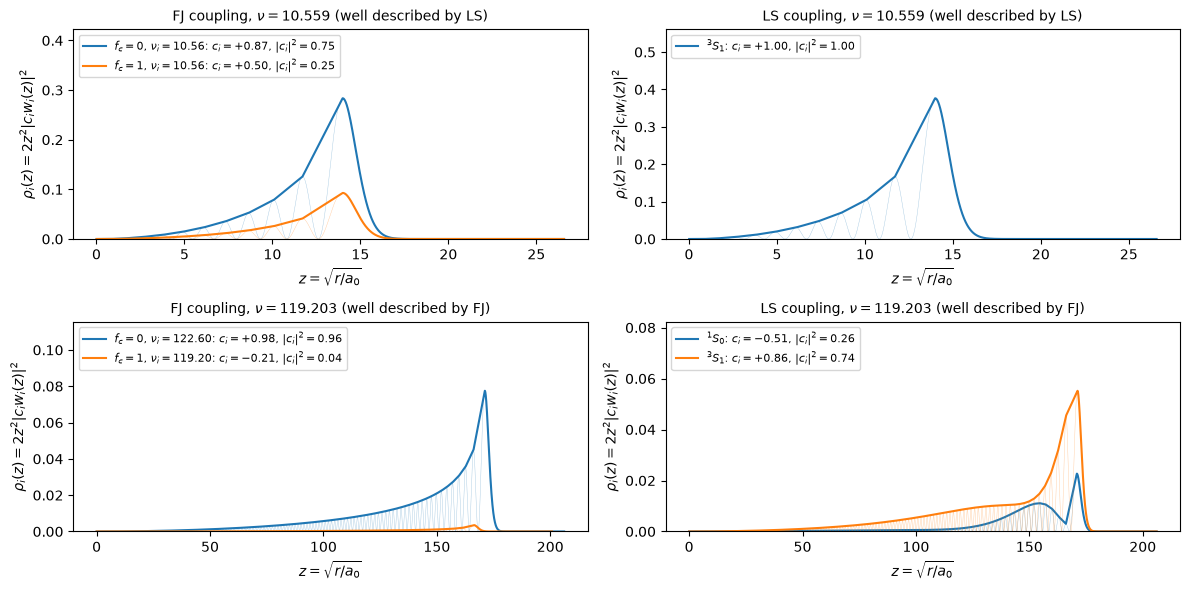

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(12, 6), sharex="row")
for row, (i, description) in enumerate([(i_ls, "well described by LS"), (i_fj, "well described by FJ")]):
    state = basis.states[i]
    for col, coupling_scheme in enumerate(["FJ", "LS"]):
        ax = axs[row, col]
        plot_density_channels(ax, state, coupling_scheme)
        ax.set_title(rf"{coupling_scheme} coupling, $\nu = {nu[i]:.3f}$ ({description})", fontsize=10)

fig.tight_layout()
plt.show()

For the low-$\nu$ state the FJ channel densities are just scaled copies of each other (same $\nu_i$),
so in LS coupling all the density collapses into the single $^3S_1$ channel.
For the high-$\nu$ state a single FJ channel dominates, while in LS coupling both channels beat over the whole extent of the wavefunction
and none of them can be neglected.

## Labeling the inner and outer part of the wavefunction

The plots above suggest that the mixing depends on the radial region:
at short distances the two FJ channel wavefunctions are nearly in phase, so one of the LS channels is small there,
while at large distances the channel with the larger $\nu_i$ survives longest.

To quantify this, we restrict the expectation values to a radial region.
The weight of channel $i$ inside $r < r_{\mathrm{cut}}$ is

$$P_i(r_{\mathrm{cut}}) = |c_i|^2 \int_0^{r_{\mathrm{cut}}} |u_i(r)|^2 \, \mathrm{d}r ,$$

and the expectation value of a quantum number $q$ (which is diagonal in the chosen coupling scheme) in the inner region is

$$\langle q \rangle_{\mathrm{inner}} = \frac{\sum_i P_i \, q_i}{\sum_i P_i}, \qquad
\sigma_{\mathrm{inner}}^2 = \frac{\sum_i P_i \, q_i^2}{\sum_i P_i} - \langle q \rangle_{\mathrm{inner}}^2 .$$

The outer region $r > r_{\mathrm{cut}}$ is treated analogously with the weights $|c_i|^2 - P_i$.
Since the transformation between the coupling schemes is unitary, the total weight $\sum_i P_i$ inside the region
is the same in both schemes.
We evaluate $J_{\mathrm{tot}}$ in the LS scheme and $F_c$ in the FJ scheme.

In [10]:
def calc_cumulative_weights(
    state: rydstate.RydbergStateMQDT, coupling_scheme: str, qn: str, z_cut: np.ndarray
) -> tuple[np.ndarray, np.ndarray]:
    """Return the weights P_i(z_cut) of all channels inside z < z_cut and the values of the quantum number qn."""
    weights = []
    qn_values = []
    for coeff, ket in get_channels(state, coupling_scheme):
        radial = ket.radial
        density = 2 * radial.w_list**2 * radial.z_list**2 * radial.dz  # same convention as Radial.norm
        cumulative = coeff**2 * np.cumsum(density)
        weights.append(np.interp(z_cut, radial.z_list, cumulative, left=0.0, right=cumulative[-1]))
        qn_values.append(ket.angular.get_qn(qn))
    return np.array(weights), np.array(qn_values)


def calc_region_exp_std(weights: np.ndarray, qn_values: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Return the expectation value and standard deviation of a quantum number for the given channel weights."""
    total = weights.sum(axis=0)
    exp = (weights * qn_values[:, None]).sum(axis=0) / total
    exp2 = (weights * qn_values[:, None] ** 2).sum(axis=0) / total
    return exp, np.sqrt(np.clip(exp2 - exp**2, 0, None))

In [11]:
# hyperfine splitting of the two ionization thresholds (6s_1/2, f_c=0 and f_c=1) in atomic units
thresholds = {
    ket.angular.f_c: state.mqdt.get_ionization_threshold(ket.angular.get_core_ket(), unit="hartree")
    for _, ket in get_channels(basis.states[mixed_indices[0]], "FJ")
}
delta_e_hfs = thresholds[1] - thresholds[0]
print(f"hyperfine splitting of the ion core: {delta_e_hfs:.3e} a.u. = {delta_e_hfs * 6.5797e6:.2f} GHz")

# radius, where the phase difference between the two FJ channels reaches pi/2
z_phase = (3 * np.pi / (2 * np.sqrt(2) * delta_e_hfs)) ** (1 / 3)
print(f"phase difference pi/2 at z = {z_phase:.1f}, i.e. r = {z_phase**2:.0f} a_0")

# fixed inner cut used for the table below
z_cut_inner = 50
print(f"phase difference at z_cut = {z_cut_inner}: {delta_e_hfs * np.sqrt(2) / 3 * z_cut_inner**3:.2f}")

hyperfine splitting of the ion core: 1.921e-06 a.u. = 12.64 GHz
phase difference pi/2 at z = 120.1, i.e. r = 14434 a_0
phase difference at z_cut = 50: 0.11


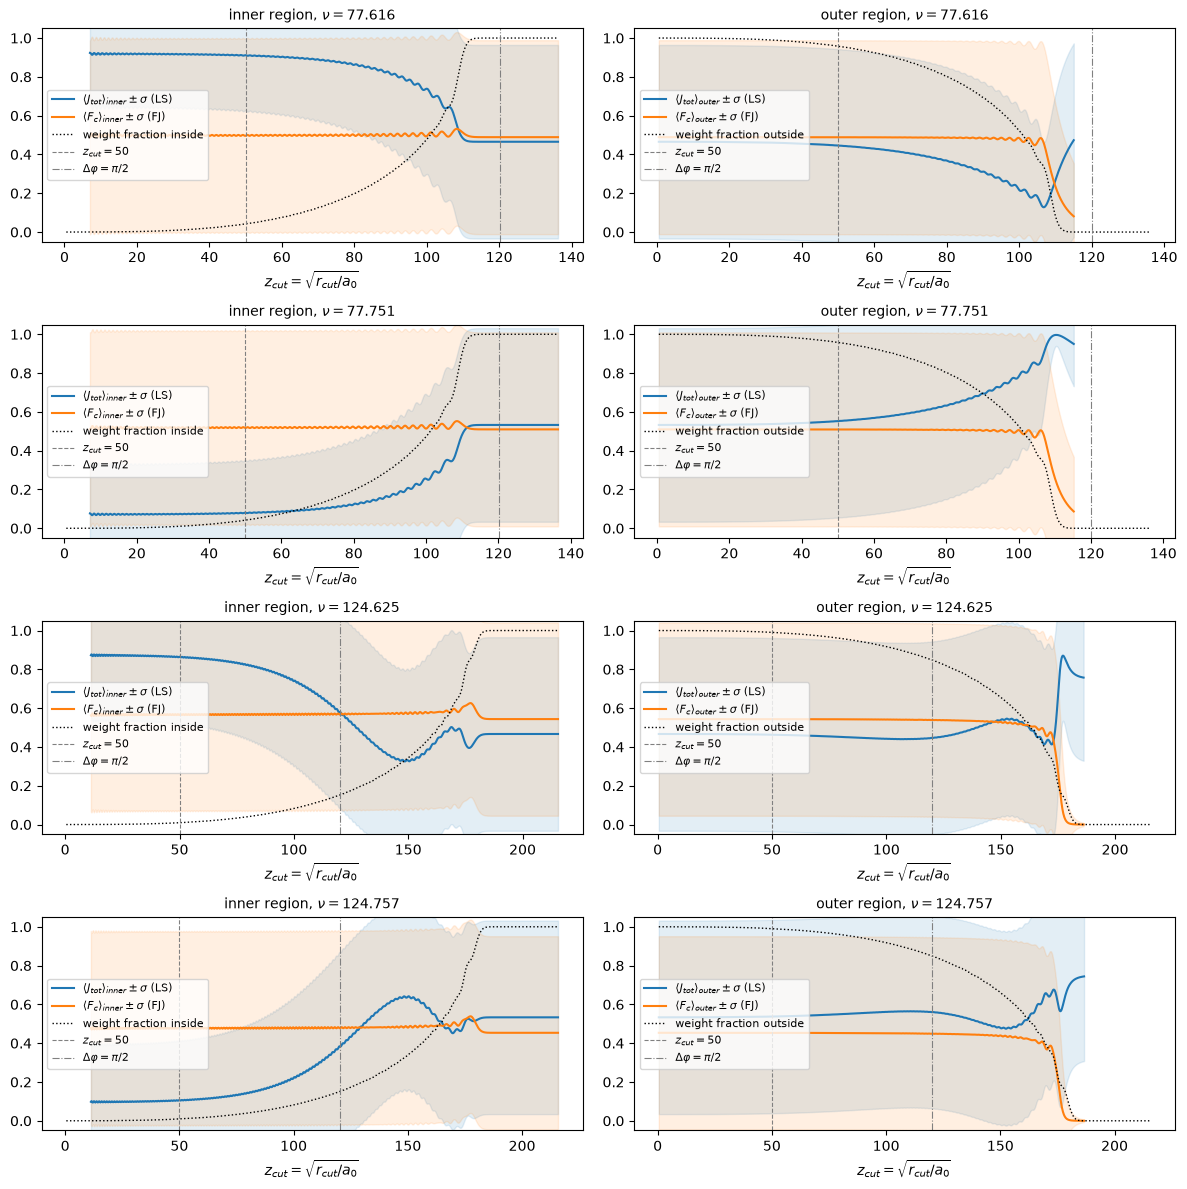

In [12]:
fig, axs = plt.subplots(n_plot, 2, figsize=(12, 3 * n_plot), sharex="row")
for row, i in enumerate(plot_indices):
    state = basis.states[i]
    z_max = max(ket.radial.z_list[-1] for _, ket in get_channels(state, "FJ"))
    z_cut = np.linspace(0.5, z_max, 1000)

    for j, (coupling_scheme, qn, label) in enumerate([("LS", "j_tot", r"J_{tot}"), ("FJ", "f_c", r"F_c")]):
        weights_inner, qn_values = calc_cumulative_weights(state, coupling_scheme, qn, z_cut)
        weights_total = weights_inner[:, -1:]
        weights_outer = weights_total - weights_inner

        for ax, weights, region in [(axs[row, 0], weights_inner, "inner"), (axs[row, 1], weights_outer, "outer")]:
            # ignore the region where (almost) no weight is left, to avoid numerical noise
            mask = weights.sum(axis=0) > 1e-4 * weights_total.sum()
            exp, std = calc_region_exp_std(weights[:, mask], qn_values)
            ax.plot(
                z_cut[mask],
                exp,
                f"C{j}",
                label=rf"$\langle {label} \rangle_{{{region}}} \pm \sigma$ ({coupling_scheme})",
            )
            ax.fill_between(z_cut[mask], exp - std, exp + std, color=f"C{j}", alpha=0.12)

    # fraction of the total weight inside z < z_cut
    fraction_inner = weights_inner.sum(axis=0) / weights_total.sum()
    axs[row, 0].plot(z_cut, fraction_inner, "k:", lw=1, label="weight fraction inside")
    axs[row, 1].plot(z_cut, 1 - fraction_inner, "k:", lw=1, label="weight fraction outside")

    for ax, region in zip(axs[row], ["inner", "outer"], strict=True):
        ax.axvline(z_cut_inner, color="grey", lw=0.8, ls="--", label=rf"$z_{{cut}} = {z_cut_inner}$")
        ax.axvline(z_phase, color="grey", lw=0.8, ls="-.", label=r"$\Delta \varphi = \pi / 2$")
        ax.set_title(rf"{region} region, $\nu = {nu[i]:.3f}$", fontsize=10)
        ax.set_xlabel(r"$z_{cut} = \sqrt{r_{cut} / a_0}$")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(loc="center left", fontsize=8)

fig.tight_layout()
plt.show()

The dash-dotted line marks the radius, where the phase difference between the two FJ channel wavefunctions reaches $\pi/2$.
Close to the core the local momentum of the electron is $k(r) \approx \sqrt{2/r}$ (in atomic units, for $r \ll 2 \nu^2 a_0$)
and the two channels differ in energy by the hyperfine splitting $\Delta E_{\mathrm{hfs}}$ of the ion core,
so the accumulated phase difference is

$$\Delta \varphi(r) \approx \Delta E_{\mathrm{hfs}} \int_0^r \frac{\mathrm{d}r'}{k(r')} = \frac{\sqrt{2}}{3} \, \Delta E_{\mathrm{hfs}} \, r^{3/2} = \frac{\sqrt{2}}{3} \, \Delta E_{\mathrm{hfs}} \, z^3 .$$

This radius is independent of $\nu$, while the classical turning point $r \approx 2 \nu^2 a_0$ grows with $\nu$.
Inside the dashed line at $z_{\mathrm{cut}} = 50$ ($r_{\mathrm{cut}} = 2500 \, a_0$) the phase difference is only about $0.1$.
The table lists the expectation values inside this radius for all mixed states.

In [13]:
print(
    f"{'idx':>4} {'nu':>8} {'weight inside':>13} | {'<J_tot>':>8} {'std':>6} (full) {'<J_tot>':>8} {'std':>6} (inner)"
    f" | {'<F_c>':>8} {'std':>6} (full) {'<F_c>':>8} {'std':>6} (inner)"
)
for i in mixed_indices:
    state = basis.states[i]
    z_cut = np.array([z_cut_inner])
    weights_j, qn_values_j = calc_cumulative_weights(state, "LS", "j_tot", z_cut)
    weights_fc, qn_values_fc = calc_cumulative_weights(state, "FJ", "f_c", z_cut)
    exp_j_inner, std_j_inner = calc_region_exp_std(weights_j, qn_values_j)
    exp_fc_inner, std_fc_inner = calc_region_exp_std(weights_fc, qn_values_fc)
    print(
        f"{i:4d} {nu[i]:8.3f} {weights_j.sum():13.3f} | {exp_j[i]:8.3f} {std_j[i]:6.3f}        "
        f"{exp_j_inner[0]:8.3f} {std_j_inner[0]:6.3f}         | {exp_fc[i]:8.3f} {std_fc[i]:6.3f}        "
        f"{exp_fc_inner[0]:8.3f} {std_fc_inner[0]:6.3f}"
    )

 idx       nu weight inside |  <J_tot>    std (full)  <J_tot>    std (inner) |    <F_c>    std (full)    <F_c>    std (inner)
 153   77.616         0.042 |    0.465  0.499           0.912  0.284         |    0.489  0.500           0.496  0.500
 154   77.751         0.042 |    0.533  0.499           0.080  0.272         |    0.510  0.500           0.517  0.500
 196   98.624         0.020 |    0.455  0.498           0.868  0.338         |    0.544  0.498           0.559  0.496
 197   98.759         0.020 |    0.544  0.498           0.111  0.314         |    0.454  0.498           0.470  0.499
 227  113.609         0.013 |    0.521  0.500           0.936  0.245         |    0.438  0.496           0.455  0.498
 228  113.743         0.013 |    0.479  0.500           0.048  0.213         |    0.560  0.496           0.578  0.494
 250  124.625         0.010 |    0.467  0.499           0.865  0.342         |    0.544  0.498           0.565  0.496
 251  124.757         0.009 |    0.533  0.499   

**Inner region:**
Restricted to $r < 2500 \, a_0$ the mixed states are again well described in LS coupling:
$\langle J_{\mathrm{tot}} \rangle_{\mathrm{inner}}$ is close to $1$ (or $0$ for the partner state of the pair)
with a standard deviation of about $0.3$ instead of $0.5$.
$F_c$ on the other hand stays completely mixed at $0.5$ in the inner region.
This is the expected behaviour: close to the core the kinetic energy of the Rydberg electron is large compared to
the hyperfine splitting of the ion core, so the electron does not resolve the two hyperfine thresholds
and the short-range (quantum defect) physics fixes the LS character.
The remaining admixture (the inner expectation value is not exactly $1$) comes from the fact that
the two LS eigenchannels $^1S_0$ and $^3S_1$ have different quantum defects,
so the FJ channel wavefunctions are not perfectly in phase at short range.

**Outer region:**
Once the phase difference between the FJ channels becomes of order one ($z \gtrsim 100$),
$J_{\mathrm{tot}}$ gets mixed (for $\nu \approx 125$ it even flips its character around $\Delta \varphi \approx \pi$).
Finally, for $r$ beyond the classical turning point of the channel with the smaller $\nu_i$,
only one FJ channel survives and $F_c$ becomes a good quantum number.
However only a small fraction of the total weight is located in this region (dotted line).

Since the radius up to which the LS description holds is fixed by $\Delta E_{\mathrm{hfs}}$ and does not grow with $\nu$,
the fraction of the wavefunction that is LS-like shrinks with increasing $\nu$ (compare the weight fraction inside $z_{\mathrm{cut}}$
in the table).

So the answer to whether these states can be labelled better is: yes, if one only looks at the inner part of the
wavefunction, they are $^3S_1$ or $^1S_0$ states in LS coupling.
The full expectation values are mixed, because the hyperfine interaction of the core recouples the angular momenta
in the outer part of the wavefunction, where the electron is slow and most of the probability density is located.